# Bistable diaphragm metafluid: 1D simulation

Discrete equation of motion for diaphragm $n$:

$$ m \, \ddot u_n = A \, p_0 v_0 \left[ \frac{1}{v_{n-1}} - \frac{1}{v_n} \right] - f(u_n) - \alpha \dot u_n $$

where $v_n = v_0 + A(u_n - u_{n+1})$ is the volume of the segment between diaphragm $n$ and $n+1$, gas pressures follow Boyle's law $p_n v_n = p_0 v_0$, and the on-site bistable force is

$$ f(u) = u^3 - a^2 u + \delta . $$

A small damping term $\alpha \dot u_n$ has been added for numerical stability — without it the snapping events drive the system unstable.

Boundary conditions: $u_0$ held fixed at $u_{\rm lo}$ (low-energy, trigger end) and $u_{N-1}$ held fixed at $u_{\rm hi}$ (high-energy).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

N = 120          # number of diaphragms

# bistable potential f(u) = u^3 - a^2*u + delta
a2    = 0.09     # = c^2 from magnet system
delta = 0.009   # asymmetry — drives high-energy to low-energy transition
                 # bistability requires |delta| < 2*a^3/(3*sqrt(3)) ~ 0.0104
                 # no propagation when = 0, good smoke test

# diaphragm and fluid parameters
m     = 1.0      # diaphragm mass
A     = 1.0      # cross-sectional area (matched to Arrieta force prefactor)
p0    = 1.0      # reference pressure
v0    = 1.0      # reference segment volume (matched to Arrieta lattice spacing d=1)
alpha = 0.05     # damping (matched to Arrieta)

# absorbing sponge layers at boundaries
n_sponge = 10
damp_max = 4.0

# trigger setup
n_trigger = 5    # number of diaphragms held fixed at the low-energy end

# time stepping
dt = 1e-4
T  = 130.0
steps = int(T / dt)
save_every = 500

# Find well positions (roots of f(u) = 0)

roots      = np.roots([1, 0, -a2, delta])
real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
u_lo, u_mid, u_hi = real_roots[0], real_roots[1], real_roots[2]

def psi(u):
    # potential, integral of f(u)
    return u**4/4 - a2*u**2/2 + delta*u

print(f"Well positions:")
print(f"  u_lo  = {u_lo:.4f}   (stable, low energy: psi = {psi(u_lo):.6f})")
print(f"  u_mid = {u_mid:.4f}   (unstable)")
print(f"  u_hi  = {u_hi:.4f}   (stable, high energy: psi = {psi(u_hi):.6f})")
print(f"  Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")

Well positions:
  u_lo  = -0.3411   (stable, low energy: psi = -0.004921)
  u_mid = 0.1185   (unstable)
  u_hi  = 0.2227   (stable, high energy: psi = 0.000387)
  Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [2]:
# Forces

# build damping array with sponge layers
damp = np.ones(N) * alpha
for i in range(n_sponge):
    strength = damp_max * ((n_sponge - i) / n_sponge) ** 2
    damp[i]         += strength
    damp[N - 1 - i] += strength


def f_bistable(u):
    # on-site bistable restoring force
    return u**3 - a2*u + delta


def pressure_force(u):
    # net gas pressure force on each diaphragm via Boyle's law
    # segment n volume: v_n = v_0 + A*(u_n - u_{n+1})
    # segment n pressure: p_n = p_0 * v_0 / v_n
    # force on diaphragm n (interior): F_n = A * (p_{n-1} - p_n)
    F = np.zeros_like(u)
    seg_vols  = v0 + A * (u[1:] - u[:-1])
    seg_vols  = np.maximum(seg_vols, 1e-6)         # clamp to avoid singularity
    pressures = p0 * v0 / seg_vols
    F[1:-1]   = A * (pressures[:-1] - pressures[1:])
    return F


def acceleration(u, v):
    # m*u_tt = pressure force - bistable force - damping*velocity
    return (pressure_force(u) - f_bistable(u) - damp * v) / m

In [3]:
# Initial conditions and time stepping (velocity Verlet)

# all diaphragms in high-energy well, first n_trigger snapped to low-energy well
u = np.ones(N) * u_hi
u[:n_trigger] = u_lo
v = np.zeros(N)

history = []
a = acceleration(u, v)

for step in range(steps):

    # velocity Verlet
    u += v * dt + 0.5 * a * dt**2

    # fix boundaries: trigger held at u_lo, right end held at u_hi
    u[:n_trigger] = u_lo
    u[-1]         = u_hi
    v[:n_trigger] = 0.0
    v[-1]         = 0.0

    a_new = acceleration(u, v)
    v    += 0.5 * (a + a_new) * dt
    a     = a_new

    if step % save_every == 0:
        history.append(u.copy())

    if step % 200000 == 0:
        mid       = 0.5 * (u_lo + u_hi)
        front     = np.where(u < mid)[0]
        front_pos = front[-1] if len(front) else 0
        print(f"  step: {step}  max u: {np.max(u):.4f}  min u: {np.min(u):.4f}  front: {front_pos}")

history = np.array(history)

  step: 0  max u: 0.2227  min u: -0.3411  front: 4
  step: 200000  max u: 0.2227  min u: -0.3894  front: 19
  step: 400000  max u: 0.2227  min u: -0.3975  front: 37
  step: 600000  max u: 0.2227  min u: -0.3911  front: 55
  step: 800000  max u: 0.2227  min u: -0.3752  front: 73
  step: 1000000  max u: 0.2227  min u: -0.3769  front: 91
  step: 1200000  max u: 0.2227  min u: -0.3761  front: 109


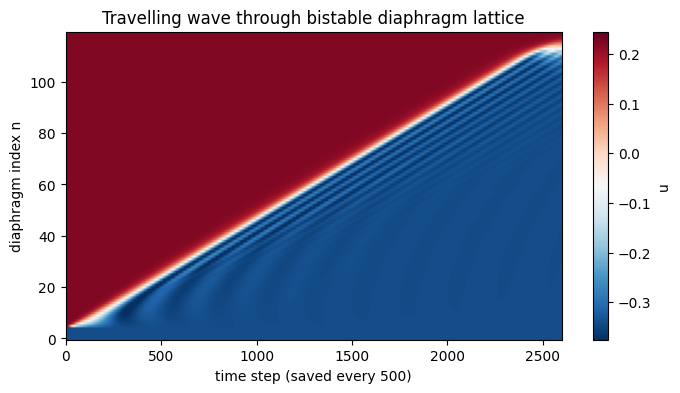

In [4]:
# Heatmap of u_n vs (time, position)

plt.figure(figsize=(8, 4))
plt.imshow(history.T, aspect='auto', origin='lower',
           vmin=u_lo*1.1, vmax=u_hi*1.1, cmap='RdBu_r')
plt.xlabel("time step (saved every {})".format(save_every))
plt.ylabel("diaphragm index n")
plt.title("Travelling wave through bistable diaphragm lattice")
plt.colorbar(label='u')
plt.show()

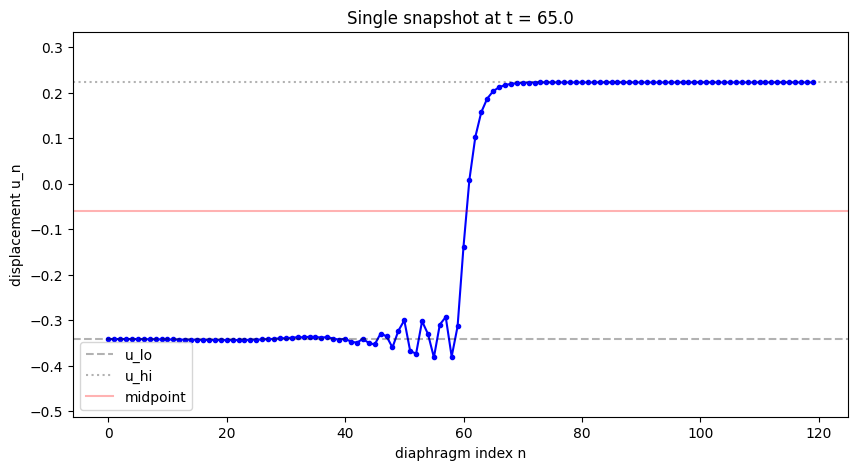

In [5]:
# Single zoomed snapshot to inspect front shape (for fitting w)

idx = len(history) // 2     # pick a snapshot in the steady-state regime
snap = history[idx]
n_array = np.arange(N)

plt.figure(figsize=(10, 5))
plt.plot(n_array, snap, 'b-', marker='o', markersize=3)
plt.axhline(u_lo,                color='k', linestyle='--', alpha=0.3, label='u_lo')
plt.axhline(u_hi,                color='k', linestyle=':',  alpha=0.3, label='u_hi')
plt.axhline(0.5*(u_lo + u_hi),   color='r', linestyle='-',  alpha=0.3, label='midpoint')
plt.xlabel('diaphragm index n')
plt.ylabel('displacement u_n')
plt.title(f'Single snapshot at t = {idx*save_every*dt:.1f}')
plt.ylim(u_lo*1.5, u_hi*1.5)
plt.legend()
plt.show()

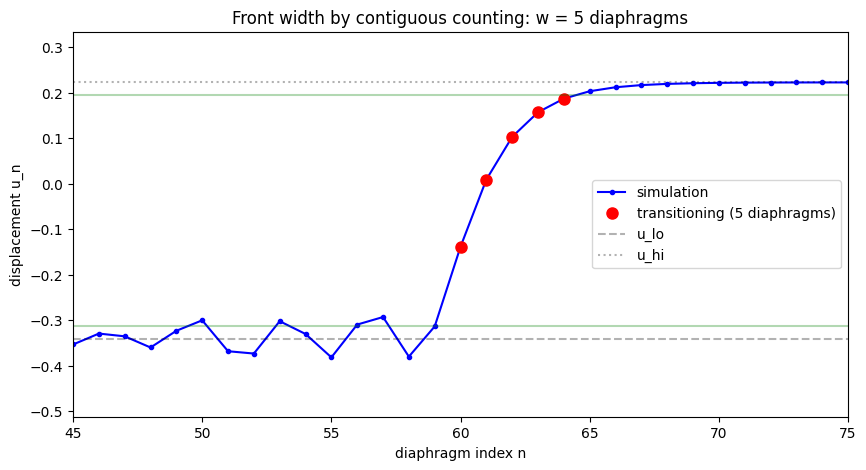

Front centre at n = 60
Front width w = 5 diaphragms
Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = 0.0636


In [6]:
# Measure front width w by counting contiguous transitioning diaphragms
# centred on the steepest gradient

# locate the front by maximum gradient
du = np.gradient(snap)
front_centre = int(np.argmax(np.abs(du)))

# expand outward from the front centre while diaphragms are in transition
eps = 0.05 * (u_hi - u_lo)
in_transition = (snap > u_lo + eps) & (snap < u_hi - eps)

# walk left from front centre
left = front_centre
while left > 0 and in_transition[left - 1]:
    left -= 1

# walk right from front centre
right = front_centre
while right < N - 1 and in_transition[right + 1]:
    right += 1

w = right - left + 1   # Inclusive counting
front_indices = np.arange(left, right + 1)

plt.figure(figsize=(10, 5))
plt.plot(n_array, snap, 'b-', marker='o', markersize=3, label='simulation')
plt.plot(n_array[front_indices], snap[front_indices], 'ro', markersize=8,
         label=f'transitioning ({w} diaphragms)')
plt.axhline(u_lo, color='k', linestyle='--', alpha=0.3, label='u_lo')
plt.axhline(u_hi, color='k', linestyle=':',  alpha=0.3, label='u_hi')
plt.axhline(u_lo + eps, color='g', linestyle='-', alpha=0.3)
plt.axhline(u_hi - eps, color='g', linestyle='-', alpha=0.3)
plt.xlabel('diaphragm index n')
plt.ylabel('displacement u_n')
plt.title(f'Front width by contiguous counting: w = {w} diaphragms')
plt.ylim(u_lo*1.5, u_hi*1.5)
plt.xlim(max(0, front_centre - 15), min(N, front_centre + 15))
plt.legend()
plt.show()

print(f'Front centre at n = {front_centre}')
print(f'Front width w = {w} diaphragms')
print(f'Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = {(u_hi - u_lo)**2 / w:.4f}')

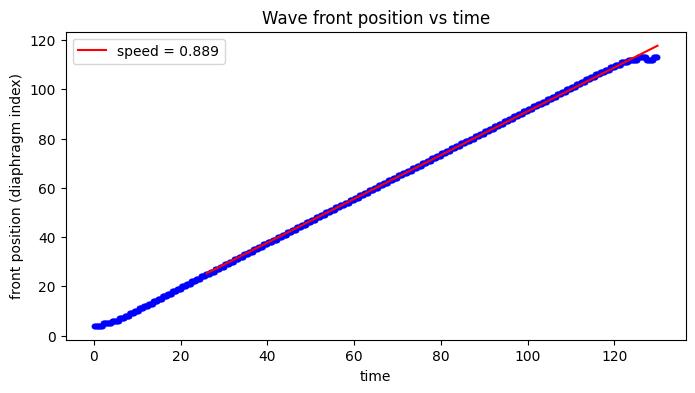

Measured wave speed: 0.8891 sites/time
Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [7]:
# Wave speed measurement: track front position vs time

mid = 0.5 * (u_lo + u_hi)
front_positions = []
for snap in history:
    front = np.where(snap < mid)[0]
    front_positions.append(front[-1] if len(front) else 0)
front_positions = np.array(front_positions)
times = np.arange(len(history)) * save_every * dt

# fit linear region (skip first 20% as transient)
steady = times > 0.2 * T
if steady.sum() > 5:
    speed, intercept = np.polyfit(times[steady], front_positions[steady], 1)
else:
    speed, intercept = 0.0, 0.0

plt.figure(figsize=(8, 4))
plt.plot(times, front_positions, 'b.', alpha=0.5)
plt.plot(times[steady], speed*times[steady] + intercept, 'r-', label=f'speed = {speed:.3f}')
plt.xlabel("time")
plt.ylabel("front position (diaphragm index)")
plt.title("Wave front position vs time")
plt.legend()
plt.show()

print(f"Measured wave speed: {speed:.4f} sites/time")
print(f"Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")

In [8]:
# Comparison with formula (13) prediction

#
# Formula (13):  v = [psi(u_hi) - psi(u_lo)] / [gamma * integral((u_z)^2)]
# Approximation: integral((u_z)^2) ~ (u_hi - u_lo)^2 / w
# Damping:       gamma ~ alpha (continuum damping ~ per-site damping at unit lattice spacing)

energy_diff = psi(u_hi) - psi(u_lo)
integral_approx = (u_hi - u_lo)**2 / w
v_predicted = energy_diff / (alpha * integral_approx)

print(f'Energy difference psi(u_hi) - psi(u_lo) = {energy_diff:.6f}')
print(f'Front width w                            = {w}')
print(f'Approximate integral (u_z)^2             = {integral_approx:.4f}')
print(f'Damping gamma ~ alpha                    = {alpha}')
print()
print(f'Predicted wave speed from formula (13)   = {v_predicted:.4f}')
print(f'Measured  wave speed from simulation     = {speed:.4f}')
print(f'Ratio predicted/measured                 = {v_predicted/speed:.2f}')

Energy difference psi(u_hi) - psi(u_lo) = 0.005309
Front width w                            = 5
Approximate integral (u_z)^2             = 0.0636
Damping gamma ~ alpha                    = 0.05

Predicted wave speed from formula (13)   = 1.6700
Measured  wave speed from simulation     = 0.8891
Ratio predicted/measured                 = 1.88


In [9]:
# Direct numerical computation of integral((u_z)^2) from the snapshot
# Compare against the (u_hi - u_lo)^2 / w approximation to see whether the
# discrepancy in v_predicted vs measured speed comes from this approximation.

# discrete derivative (lattice spacing = 1)
du_dn = np.gradient(snap)
integral_direct = np.sum(du_dn**2)

v_predicted_direct = energy_diff / (alpha * integral_direct)

print(f'Integral approximation (u_hi - u_lo)^2 / w   = {integral_approx:.4f}')
print(f'Integral computed directly from snapshot     = {integral_direct:.4f}')
print(f'Ratio direct/approximation                   = {integral_direct/integral_approx:.2f}')
print()
print(f'Predicted v using approximation              = {v_predicted:.4f}')
print(f'Predicted v using direct integral            = {v_predicted_direct:.4f}')
print(f'Measured v from simulation                   = {speed:.4f}')

Integral approximation (u_hi - u_lo)^2 / w   = 0.0636
Integral computed directly from snapshot     = 0.0364
Ratio direct/approximation                   = 0.57

Predicted v using approximation              = 1.6700
Predicted v using direct integral            = 2.9156
Measured v from simulation                   = 0.8891


        dt    Cauchy error   order
   8.0e-04      1.9287e-04      --
   4.0e-04      9.6407e-05    1.00
   2.0e-04      4.8196e-05    1.00
   1.0e-04      2.4096e-05    1.00


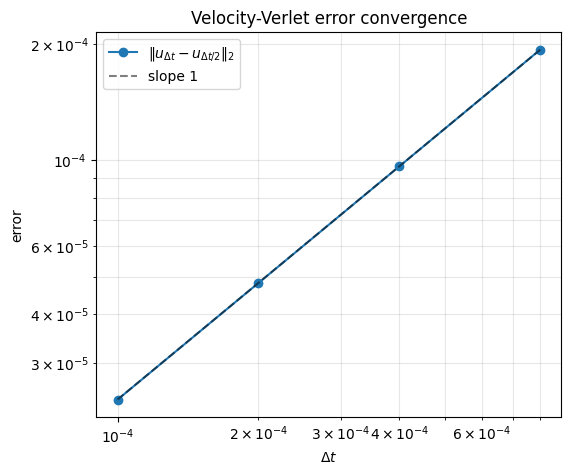

In [10]:
# Error convergence test for the velocity-Verlet scheme
# Cauchy self-convergence: error(dt) = || u_dt(T) - u_{dt/2}(T) ||_2
# Slope on the log-log plot = observed order of accuracy.

def evolve(dt_run, T_run=40.0):
    u = np.ones(N) * u_hi; u[:n_trigger] = u_lo
    v = np.zeros(N); a = acceleration(u, v)
    for _ in range(int(round(T_run / dt_run))):
        u += v * dt_run + 0.5 * a * dt_run**2
        u[:n_trigger] = u_lo; u[-1] = u_hi
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        a_new = acceleration(u, v); v += 0.5 * (a + a_new) * dt_run; a = a_new
    return u

dts    = np.array([8e-4, 4e-4, 2e-4, 1e-4, 5e-5])
sols   = [evolve(d) for d in dts]
errs   = np.array([np.sqrt(np.sum((sols[i] - sols[i+1])**2)) for i in range(len(dts)-1)])
dt_err = dts[:-1]
orders = np.log2(errs[:-1] / errs[1:])

print(f"{'dt':>10}{'Cauchy error':>16}{'order':>8}")
for i in range(len(errs)):
    o = f"{orders[i-1]:.2f}" if i > 0 else "--"
    print(f"{dt_err[i]:10.1e}{errs[i]:16.4e}{o:>8}")

plt.figure(figsize=(6, 5))
plt.loglog(dt_err, errs, 'o-', label=r'$\|u_{\Delta t}-u_{\Delta t/2}\|_2$')
plt.loglog(dt_err, errs[0] / dt_err[0]    * dt_err,     'k--', alpha=0.5, label='slope 1')
plt.xlabel(r'$\Delta t$'); plt.ylabel('error')
plt.title('Velocity-Verlet error convergence')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

## Parameter sweep: diagnosing the continuum regime (D3 & D4)

The Arrieta wave-speed formula is derived in the continuum limit — it should become accurate as the coupling strength $A$ increases and the kink profile spreads over many lattice sites.  
Below we:
1. Wrap the simulation into a single `run_sim` function.
2. Sweep $A \in \{0.5, 1, 2, 5, 10\}$ to find where the ratio $v_\text{pred}/v_\text{sim} \to 1$ (D4 continuum-validity diagnostic).
3. Run a full 45-combination grid over $(A, \delta, \alpha)$ and save to `results/wave_speed_sweep.csv` (D3).

In [11]:
def run_sim(A, delta, alpha, N=120, T=150.0, dt=1e-4,
            n_sponge=10, damp_max=4.0, n_trigger=5):
    """
    Run one simulation and return (v_measured, v_predicted, ratio).

    v_predicted uses the Arrieta formula with the integral computed directly
    from a mid-run snapshot (more accurate than the (Δu)²/w approximation).
    Returns (nan, nan, nan) if the wave does not propagate.
    """
    a2 = 0.09
    m = 1.0; p0 = 1.0; v0 = 1.0

    # Well positions (depend on delta only, a2 is fixed)
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    if len(real_roots) < 3:
        return np.nan, np.nan, np.nan
    u_lo, _, u_hi = real_roots

    def psi(u):
        return u**4/4 - a2*u**2/2 + delta*u

    # Damping array: bulk damping + sponge layers at both ends
    damp = np.ones(N) * alpha
    for i in range(n_sponge):
        strength = damp_max * ((n_sponge - i) / n_sponge)**2
        damp[i]         += strength
        damp[N - 1 - i] += strength

    def f_bistable(u):
        return u**3 - a2*u + delta

    def pressure_force(u):
        F = np.zeros_like(u)
        seg_vols  = v0 + A * (u[1:] - u[:-1])
        seg_vols  = np.maximum(seg_vols, 1e-6)
        pressures = p0 * v0 / seg_vols
        F[1:-1]   = A * (pressures[:-1] - pressures[1:])
        return F

    def accel(u, v):
        return (pressure_force(u) - f_bistable(u) - damp * v) / m

    # Initial conditions
    u = np.ones(N) * u_hi
    u[:n_trigger] = u_lo
    v = np.zeros(N)

    steps      = int(T / dt)
    save_every = 500
    history    = []
    a_arr      = accel(u, v)

    for step in range(steps):
        u     += v * dt + 0.5 * a_arr * dt**2
        u[:n_trigger] = u_lo;  u[-1] = u_hi
        v[:n_trigger] = 0.0;   v[-1] = 0.0
        a_new  = accel(u, v)
        v     += 0.5 * (a_arr + a_new) * dt
        a_arr  = a_new
        if step % save_every == 0:
            history.append(u.copy())

    history = np.array(history)

    # --- Wave speed measurement ---
    mid = 0.5 * (u_lo + u_hi)
    front_pos = []
    for snap in history:
        front = np.where(snap < mid)[0]
        front_pos.append(front[-1] if len(front) else 0)
    front_pos = np.array(front_pos, dtype=float)
    times     = np.arange(len(history)) * save_every * dt

    steady = times > 0.2 * T
    if steady.sum() < 5 or front_pos[steady].std() < 1e-6:
        return np.nan, np.nan, np.nan
    v_measured, _ = np.polyfit(times[steady], front_pos[steady], 1)
    if v_measured < 1e-6:
        return np.nan, np.nan, np.nan

    # --- Arrieta formula: use direct integral from mid-run snapshot ---
    snap_mid       = history[len(history) // 2]
    du_dn          = np.gradient(snap_mid)
    integral_direct = np.sum(du_dn**2)
    energy_diff    = psi(u_hi) - psi(u_lo)

    if integral_direct < 1e-12:
        return v_measured, np.nan, np.nan

    v_predicted = energy_diff / (alpha * integral_direct)
    ratio       = v_predicted / v_measured

    return v_measured, v_predicted, ratio

 delta       v_sim      v_pred     ratio
------------------------------------------


<>:24: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:24: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/6w/jxzr0g515235blzrwbrkjxlc0000gp/T/ipykernel_13376/4244505320.py:24: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  plt.xlabel('Coupling strength $\delta$', fontsize=12)


 0.001      0.4085      0.4199     1.028
 0.003      0.7465      0.8131     1.089
 0.005      0.7871      1.0697     1.359
 0.007      0.7950      1.2911     1.624
 0.009      0.7972      1.4480     1.816


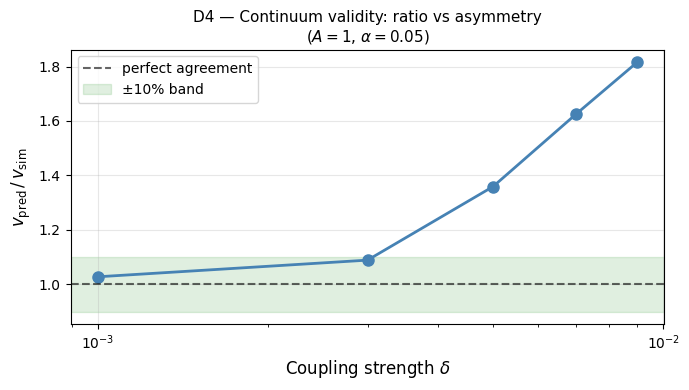

In [12]:
# D4: Continuum-validity diagnostic — sweep asymmetry delta
# Expect v_pred / v_sim → 1 as delta increases (kink spreads over more sites → continuum limit)
# Keep A and alpha fixed at baseline values.

delta_values = [0.001, 0.003, 0.005, 0.007, 0.009]

print(f"{'delta':>6}  {'v_sim':>10}  {'v_pred':>10}  {'ratio':>8}")
print("-" * 42)

results_delta = []
for delta_val in delta_values:
    v_m, v_p, r = run_sim(A=1.0, delta=delta_val, alpha=0.05)
    results_delta.append((delta_val, v_m, v_p, r))
    r_str = f"{r:.3f}" if not np.isnan(r) else "  NaN "
    print(f"{delta_val:>6.3f}  {v_m:>10.4f}  {v_p:>10.4f}  {r_str:>8}")

delta_arr    = np.array([x[0] for x in results_delta])
ratio_delta  = np.array([x[3] for x in results_delta])

plt.figure(figsize=(7, 4))
plt.semilogx(delta_arr, ratio_delta, 'o-', color='steelblue', markersize=8, linewidth=2)
plt.axhline(1.0, color='k',     linestyle='--', alpha=0.6, label='perfect agreement')
plt.axhspan(0.9, 1.1, alpha=0.12, color='green', label='±10% band')
plt.xlabel('Coupling strength $\delta$', fontsize=12)
plt.ylabel(r'$v_\mathrm{pred} \,/\, v_\mathrm{sim}$', fontsize=12)
plt.title('D4 — Continuum validity: ratio vs asymmetry\n'
          r'($A = 1$, $\alpha = 0.05$)', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# D3: Full parameter sweep over (A, delta, alpha)
# 5 × 3 × 3 = 45 combinations; results saved to results/wave_speed_sweep.csv
# Uses N=120, T=150 per run (~1.5 M steps each).  Expect a few minutes total.

import itertools, csv, os

A_sweep     = [0.5, 1.0, 2.0, 5.0, 10.0]
delta_sweep = [0.001, 0.003, 0.009]
alpha_sweep = [0.02,  0.05,  0.1]

combos = list(itertools.product(A_sweep, delta_sweep, alpha_sweep))
print(f"Running {len(combos)} parameter combinations …\n")
print(f"{'#':>3}  {'A':>5}  {'delta':>7}  {'alpha':>6}  {'v_sim':>8}  {'v_pred':>8}  {'ratio':>7}")
print("-" * 58)

sweep_results = []
for i, (A_val, d_val, al_val) in enumerate(combos, 1):
    v_m, v_p, r = run_sim(A_val, delta=d_val, alpha=al_val)
    sweep_results.append([A_val, d_val, al_val, v_m, v_p, r])
    r_str  = f"{r:7.3f}" if not np.isnan(r) else "    NaN"
    vm_str = f"{v_m:8.4f}" if not np.isnan(v_m) else "     NaN"
    vp_str = f"{v_p:8.4f}" if not np.isnan(v_p) else "     NaN"
    print(f"{i:3d}  {A_val:5.1f}  {d_val:7.3f}  {al_val:6.2f}  {vm_str}  {vp_str}  {r_str}")

os.makedirs('results', exist_ok=True)
with open('results/wave_speed_sweep.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['A', 'delta', 'alpha', 'v_measured', 'v_predicted', 'ratio'])
    writer.writerows(sweep_results)

print(f"\nSaved {len(sweep_results)} rows → results/wave_speed_sweep.csv")

Running 45 parameter combinations …

  #      A    delta   alpha     v_sim    v_pred    ratio
----------------------------------------------------------
  1    0.5    0.001    0.02    0.1755    0.5964    3.399
  2    0.5    0.001    0.05    0.1162    0.2402    2.067
  3    0.5    0.001    0.10    0.0687    0.1190    1.733
  4    0.5    0.003    0.02    0.3641    1.0566    2.902
  5    0.5    0.003    0.05    0.3275    0.4889    1.493
  6    0.5    0.003    0.10    0.2514    0.2982    1.186
  7    0.5    0.009    0.02    0.4655    1.8804    4.040
  8    0.5    0.009    0.05    0.4490    1.0571    2.354
  9    0.5    0.009    0.10    0.4211    0.6622    1.573
 10    1.0    0.001    0.02    0.6742    0.7980    1.184
 11    1.0    0.001    0.05    0.4085    0.4199    1.028
 12    1.0    0.001    0.10    0.2208    0.2233    1.011
 13    1.0    0.003    0.02    0.7898    1.5064    1.907
 14    1.0    0.003    0.05    0.7465    0.8131    1.089
 15    1.0    0.003    0.10    0.5533    0.5653  

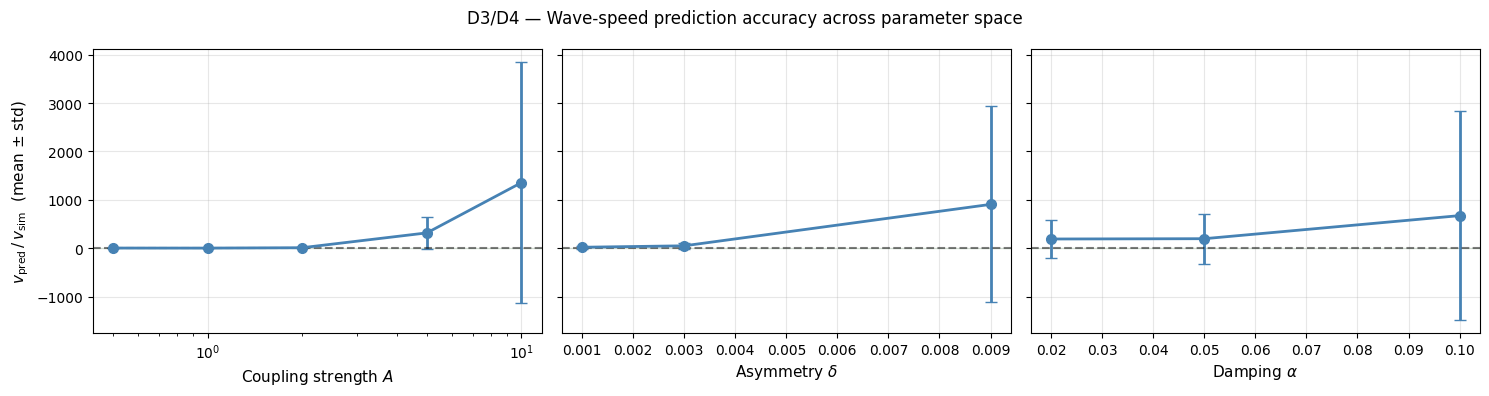

Valid runs:  43 / 45
Ratio range: 0.985 – 8156.712
Within ±10% of 1: 5 runs


In [14]:
# D3 / D4 visualisation: ratio v_pred/v_sim across parameter space

data = np.array(sweep_results, dtype=float)
A_col, d_col, al_col, vm_col, vp_col, r_col = data.T

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

params = [
    (A_col,  A_sweep,     'Coupling strength $A$',  True),
    (d_col,  delta_sweep, 'Asymmetry $\\delta$',    False),
    (al_col, alpha_sweep, 'Damping $\\alpha$',      False),
]

for ax, (col, vals, label, logscale) in zip(axes, params):
    means = [np.nanmean(r_col[col == v]) for v in vals]
    stds  = [np.nanstd (r_col[col == v]) for v in vals]
    ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=4,
                color='steelblue', linewidth=2, markersize=7)
    ax.axhline(1.0, color='k', linestyle='--', alpha=0.5)
    ax.axhspan(0.9, 1.1, alpha=0.12, color='green')
    if logscale:
        ax.set_xscale('log')
    ax.set_xlabel(label, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$v_\mathrm{pred}\,/\,v_\mathrm{sim}$  (mean ± std)', fontsize=11)
fig.suptitle('D3/D4 — Wave-speed prediction accuracy across parameter space', fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
valid = ~np.isnan(r_col)
print(f"Valid runs:  {valid.sum()} / {len(r_col)}")
print(f"Ratio range: {np.nanmin(r_col):.3f} – {np.nanmax(r_col):.3f}")
print(f"Within ±10% of 1: {np.sum(np.abs(r_col[valid] - 1) < 0.1)} runs")

## Physical interpretation of the parameter sweep

### Why larger $\delta$ makes the formula worse

$\delta$ is the asymmetry of the bistable potential — it controls how much lower in energy the $u_\text{lo}$ well is compared to $u_\text{hi}$. A larger $\delta$ means a bigger energy difference $\Delta\psi = \psi(u_\text{hi}) - \psi(u_\text{lo})$, which drives the transition wave harder and makes it travel faster.

Crucially, a faster wave also has a narrower width. The transition front passes each diaphragm in less time, so fewer diaphragms are simultaneously "in transition" between the two wells. With only 3–5 lattice sites spanning the width, the system is far from the smooth continuum profile that the Arrieta formula assumes. The formula therefore over-predicts: it thinks the wave is spreading its gradient over a wide smooth front, but in reality the front is sharp and highly discrete.

As $\delta \to 0$ the two wells become one, the driving force vanishes, the wave slows to near-zero, and the kink spreads over many sites — this is the continuum limit. But it is also a physically marginal regime in which a tiny perturbation can pin the wave altogether.

### Why larger $\alpha$ makes the formula better

The Arrieta formula is fundamentally an energy balance: the potential energy released per unit advance of the front equals the energy dissipated by viscous damping. This balance is exact only in the overdamped limit, where inertial effects (kinetic energy stored in the moving diaphragms) are negligible.

$$v = \frac{\psi(u_\text{hi}) - \psi(u_\text{lo})}{\alpha \int_{-\infty}^{\infty} \left(\frac{du}{d\xi}\right)^2 d\xi}$$

At low $\alpha$ the wave is underdamped: diaphragms overshoot their equilibrium, ring down, and carry kinetic energy that the formula ignores. This kinetic energy acts as an additional effective resistance, slowing the wave below the formula's prediction (ratio $> 1$).

As $\alpha$ increases the system becomes more overdamped: diaphragms snap directly to $u_\text{lo}$ without oscillating, kinetic energy is negligible, and the formula's energy-balance assumption becomes accurate. The price is that the wave also slows down — high damping is only useful if the wave still propagates at all.

### Why $A \approx 1$ is the only regime with accurate predictions

$A$ enters the segment volume as $v_n = v_0 + A(u_n - u_{n+1})$. The displacement difference across the kink is of order $u_\text{hi} - u_\text{lo} \approx 0.56$. For volumes to remain positive throughout the kink transition we need

$$A \cdot (u_\text{hi} - u_\text{lo}) \lesssim v_0 \quad \Longrightarrow \quad A \lesssim \frac{v_0}{0.56} \approx 1.8$$

At $A \gtrsim 2$ the compressed segments hit zero volume and the code clamps them to $10^{-6}$, introducing a large unphysical pressure force that effectively pins the kink. This is why $v_\text{sim}$ collapses at $A = 5, 10$ — the wave is stalling against the clamped segments, not propagating freely. The formula predicts an astronomically high speed because it does not know the wave has stalled.

This is a fundamental difference from the spring-coupled Nadkarni system, where there is no volume constraint: increasing the spring stiffness always increases coupling without any physical ceiling. In the fluid-coupled system, increasing $A$ without also increasing $v_0$ (the reference volume) drives the fluid into a near-incompressible state, which resists rather than assists wave propagation.

The practical implication is that the continuum limit in this fluid-coupled system cannot be reached by increasing $A$ alone. Instead, the relevant control parameters are $\delta$ (kink width) and $\alpha$ (overdamping), both of which should be small and large respectively to approach the regime where the Arrieta formula is quantitatively accurate.

Running extra alpha values …
  alpha=0.01  v_sim=0.7530  v_pred=1.2999  ratio=1.726
  alpha=0.15  v_sim=0.1498  v_pred=0.1513  ratio=1.010
  alpha=0.20  v_sim=0.1133  v_pred=0.1141  ratio=1.007
  alpha=0.30  v_sim=0.0775  v_pred=0.0759  ratio=0.979

  alpha     v_sim     ratio
------------------------------
  0.010    0.7530     1.726
  0.020    0.6742     1.184
  0.050    0.4085     1.028
  0.100    0.2208     1.011
  0.150    0.1498     1.010
  0.200    0.1133     1.007
  0.300    0.0775     0.979


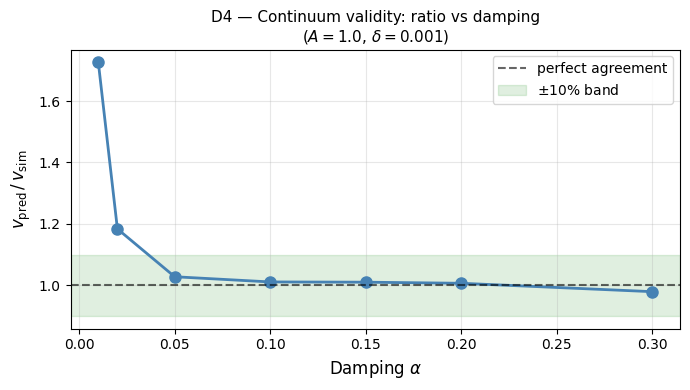

Continuum formula accurate (ratio within 10%) for alpha >= 0.05


In [15]:
# D4: Continuum-validity diagnostic — ratio vs damping alpha
# Fixed A=1, delta=0.001.  Reuse the 3 points already in sweep_results,
# then run 4 extra alpha values to fill out the curve.

# Extract existing points from sweep_results (A=1, delta=0.001)
existing = {row[2]: (row[3], row[4], row[5])
            for row in sweep_results
            if row[0] == 1.0 and row[1] == 0.001}

# Run extra alpha values
extra_alphas = [0.01, 0.15, 0.20, 0.30]
print("Running extra alpha values …")
for al in extra_alphas:
    v_m, v_p, r = run_sim(A=1.0, delta=0.001, alpha=al)
    existing[al] = (v_m, v_p, r)
    print(f"  alpha={al:.2f}  v_sim={v_m:.4f}  v_pred={v_p:.4f}  ratio={r:.3f}")

# Combine and sort
alpha_vals = sorted(existing.keys())
ratios     = [existing[a][2] for a in alpha_vals]
v_sims     = [existing[a][0] for a in alpha_vals]

print(f"\n{'alpha':>7}  {'v_sim':>8}  {'ratio':>8}")
print("-" * 30)
for a, vm, r in zip(alpha_vals, v_sims, ratios):
    r_str = f"{r:.3f}" if not np.isnan(r) else "  NaN"
    print(f"{a:7.3f}  {vm:8.4f}  {r_str:>8}")

# Plot
alpha_arr = np.array(alpha_vals)
ratio_arr = np.array(ratios, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alpha_arr, ratio_arr, 'o-', color='steelblue', markersize=8, linewidth=2)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.6, label='perfect agreement')
ax.axhspan(0.9, 1.1, alpha=0.12, color='green', label=r'$\pm$10% band')
ax.set_xlabel(r'Damping $\alpha$', fontsize=12)
ax.set_ylabel(r'$v_\mathrm{pred}\,/\,v_\mathrm{sim}$', fontsize=12)
ax.set_title('D4 — Continuum validity: ratio vs damping\n'
             r'($A = 1.0$, $\delta = 0.001$)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Report threshold
in_band = np.where(~np.isnan(ratio_arr) & (np.abs(ratio_arr - 1) < 0.1))[0]
if len(in_band):
    print(f"Continuum formula accurate (ratio within 10%) for alpha >= {alpha_arr[in_band[0]]:.2f}")